In [1]:
# Welcome to your new notebook
# Type here in the cell editor to add code!


StatementMeta(, e65bec84-de03-4b4d-a2c8-ed85b69e6a89, 3, Finished, Available, Finished, False)

In [2]:
%pip install networkx

StatementMeta(, e65bec84-de03-4b4d-a2c8-ed85b69e6a89, 8, Finished, Available, Finished, True)


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.



- NetworkX is a Python library used to represent and analyze networks/graphs.
- NetworkX creates the graph structure, but matplotlib helps us visualize the graph.
- I converted the Spark DataFrame to Pandas because NetworkX operates in the Python environment.

In [3]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

StatementMeta(, e65bec84-de03-4b4d-a2c8-ed85b69e6a89, 10, Finished, Available, Finished, False)

# Dynamic Method

# Read  Gold relationship table

Why it is matter?

relationship table is the source for the graph

Who is the parent?

Who is the child?


What relationship exists?

In [4]:
relationship_pd = spark.sql("""
    SELECT
        site_id,
        building_id,
        parent_asset_id,
        child_asset_id,
        relationship_type
    FROM dbo.gold_asset_relationship
""").toPandas()

display(relationship_pd)

StatementMeta(, e65bec84-de03-4b4d-a2c8-ed85b69e6a89, 11, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, a3922acd-bf1a-4f30-843a-2f87eccf3751)

# Read your Asset Dimension

why it is main:
need this because  graph should show:

The relationship table contains only asset IDs, so I joined it logically with the asset dimension to get descriptive information such as asset name and asset type. This makes the graph understandable for users.

In [5]:
asset_pd = spark.sql("""
    SELECT
        asset_id,
        asset_name,
        asset_type
    FROM dbo.gold_dim_asset
""").toPandas()

display(asset_pd)

StatementMeta(, e65bec84-de03-4b4d-a2c8-ed85b69e6a89, 12, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, a3f7b92c-c894-4d43-bd9b-77628b208c18)

# Create the reusable graph function

In [6]:
def build_asset_graph(relationship_df, site_id):

    site_relationships = relationship_df[
        relationship_df["site_id"] == site_id
    ]

    G = nx.DiGraph()

    for _, row in site_relationships.iterrows():

        G.add_edge(
            row["parent_asset_id"],
            row["child_asset_id"],
            relationship_type=row["relationship_type"]
        )

    return G

StatementMeta(, e65bec84-de03-4b4d-a2c8-ed85b69e6a89, 13, Finished, Available, Finished, False)

# Create asset labels

In [7]:
asset_lookup = (
    asset_pd
    .drop_duplicates("asset_id")
    .set_index("asset_id")
)

StatementMeta(, e65bec84-de03-4b4d-a2c8-ed85b69e6a89, 14, Finished, Available, Finished, False)

In [8]:
def create_asset_labels(graph, asset_lookup):

    labels = {}

    for asset_id in graph.nodes():

        if asset_id in asset_lookup.index:

            asset_name = asset_lookup.loc[
                asset_id, "asset_name"
            ]

            asset_type = asset_lookup.loc[
                asset_id, "asset_type"
            ]

            labels[asset_id] = (
                f"{asset_id}\n"
                f"{asset_name}\n"
                f"({asset_type})"
            )

        else:
            labels[asset_id] = asset_id

    return labels

StatementMeta(, e65bec84-de03-4b4d-a2c8-ed85b69e6a89, 15, Finished, Available, Finished, False)

# Create the reusable visualization function

In [9]:
def visualize_asset_graph(graph, asset_lookup, site_id):

    plt.figure(figsize=(10, 6))

    labels = create_asset_labels(
        graph,
        asset_lookup
    )

    # Create hierarchical levels
    levels = list(
        nx.topological_generations(graph)
    )

    pos = {}

    for level, nodes in enumerate(levels):

        nodes = list(nodes)

        for i, node in enumerate(nodes):

            pos[node] = (
                i - (len(nodes) - 1) / 2,
                -level
            )

    nx.draw(
        graph,
        pos,
        labels=labels,
        with_labels=True,
        node_size=3500,
        arrows=True,
        arrowsize=20,
        font_size=8,
        font_weight="bold"
    )

    plt.title(
        f"{site_id} Asset Hierarchy & Connectivity",
        fontsize=16,
        fontweight="bold"
    )

    plt.axis("off")
    plt.show()

StatementMeta(, e65bec84-de03-4b4d-a2c8-ed85b69e6a89, 16, Finished, Available, Finished, False)

# **Test with S001 to S005**

StatementMeta(, e65bec84-de03-4b4d-a2c8-ed85b69e6a89, 17, Finished, Available, Finished, False)

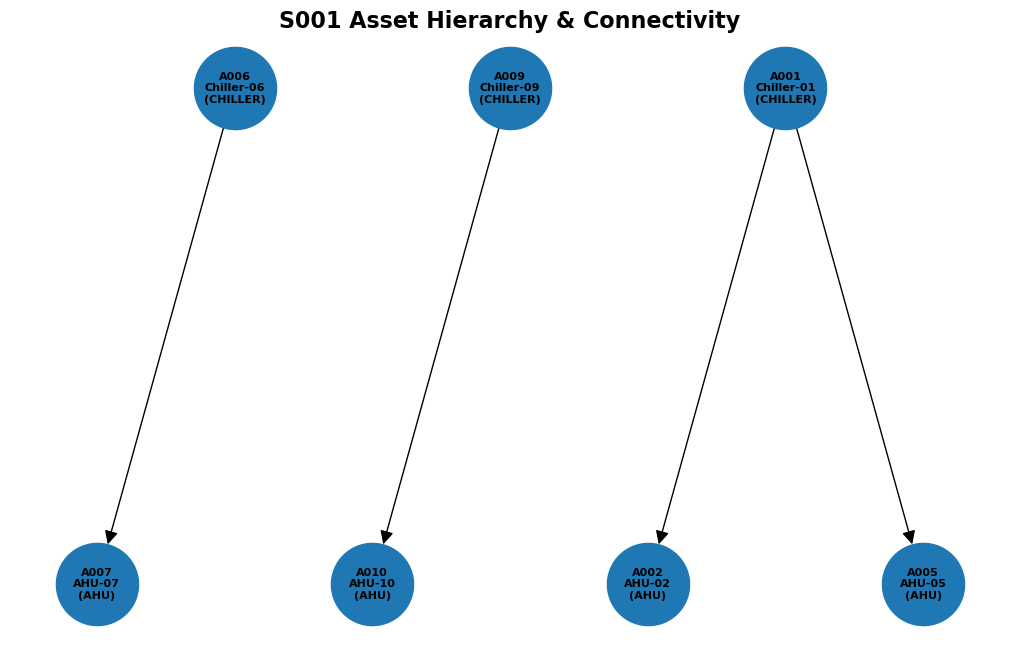

In [10]:
G_s001 = build_asset_graph(
    relationship_pd,
    "S001"
)

visualize_asset_graph(
    G_s001,
    asset_lookup,
    "S001"
)

StatementMeta(, e65bec84-de03-4b4d-a2c8-ed85b69e6a89, 18, Finished, Available, Finished, False)

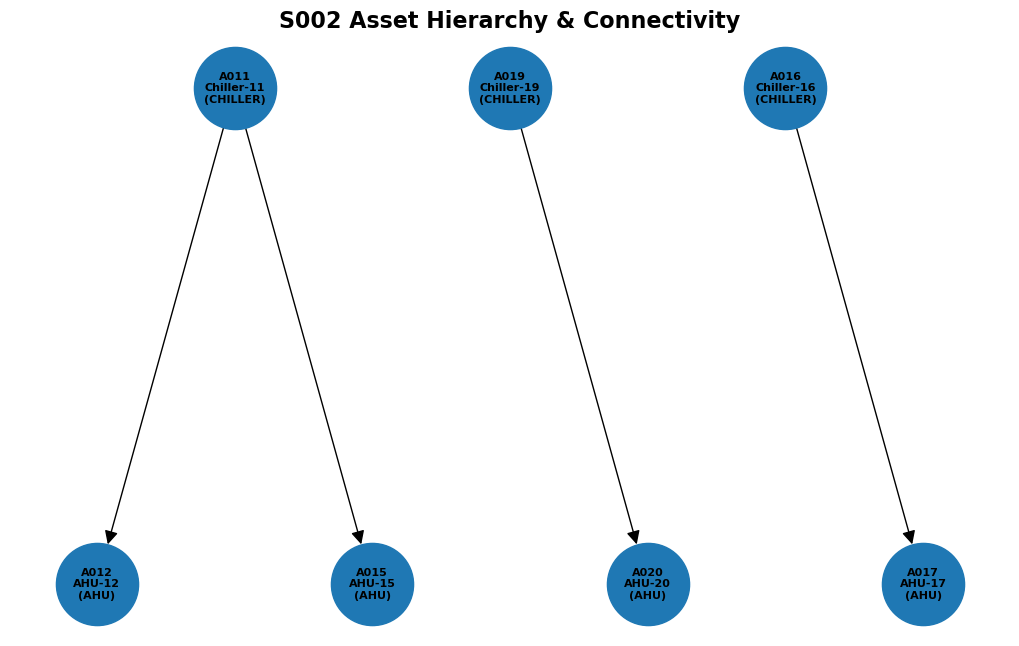

In [11]:
G_s002 = build_asset_graph(
    relationship_pd,
    "S002"
)

visualize_asset_graph(
    G_s002,
    asset_lookup,
    "S002"
)

StatementMeta(, e65bec84-de03-4b4d-a2c8-ed85b69e6a89, 19, Finished, Available, Finished, False)

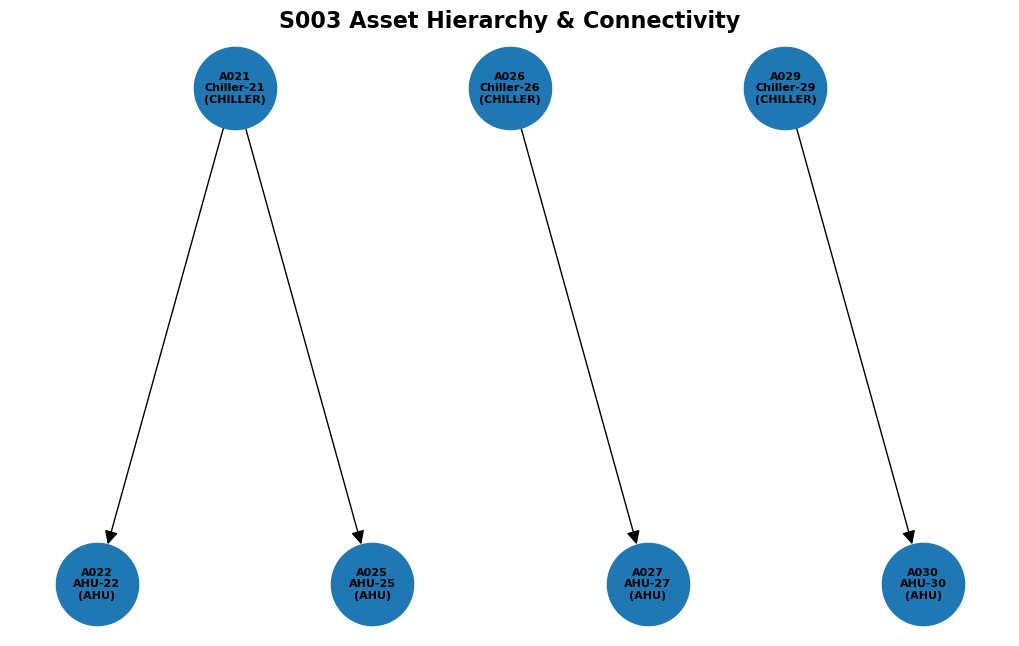

In [12]:
G_s003 = build_asset_graph(
    relationship_pd,
    "S003"
)

visualize_asset_graph(
    G_s003,
    asset_lookup,
    "S003"
)

StatementMeta(, e65bec84-de03-4b4d-a2c8-ed85b69e6a89, 20, Finished, Available, Finished, False)

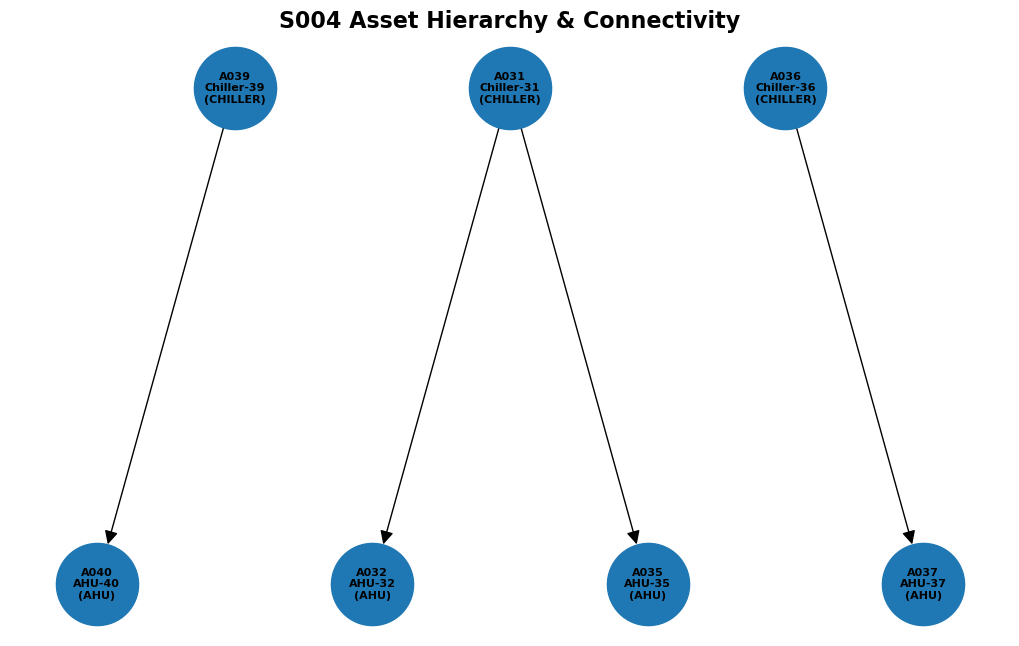

In [13]:
G_s004 = build_asset_graph(
    relationship_pd,
    "S004"
)

visualize_asset_graph(
    G_s004,
    asset_lookup,
    "S004"
)

StatementMeta(, e65bec84-de03-4b4d-a2c8-ed85b69e6a89, 21, Finished, Available, Finished, False)

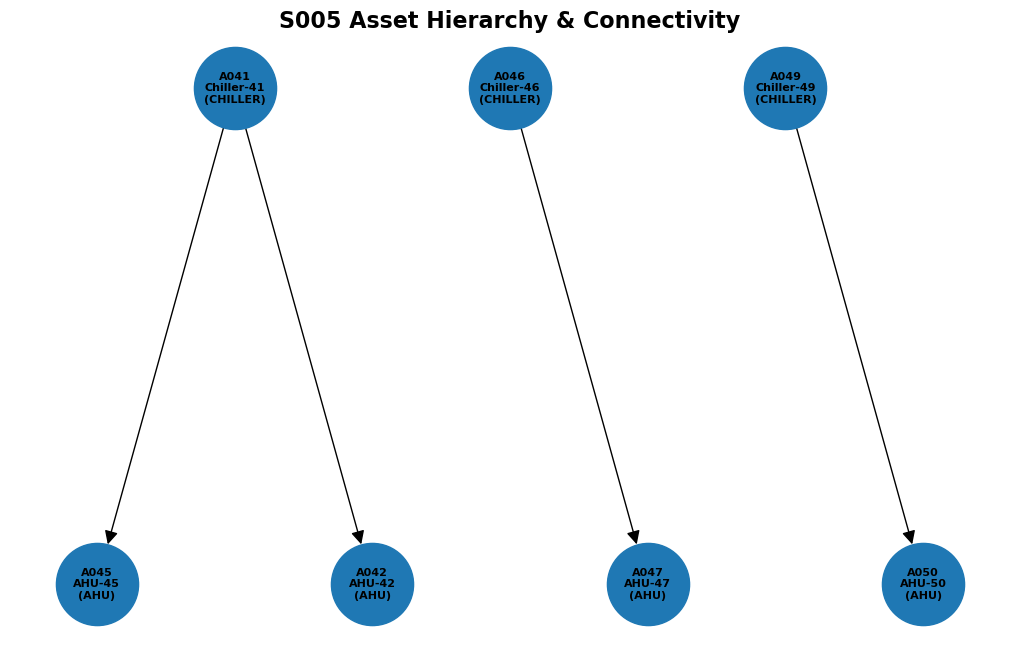

In [14]:
G_s005 = build_asset_graph(
    relationship_pd,
    "S005"
)

visualize_asset_graph(
    G_s005,
    asset_lookup,
    "S005"
)